# Market - sentiment independence

In [2]:
import os
import sys
# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join('..', '..')) 
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis" 

import seaborn as sns
import matplotlib.pyplot as plt
import numpy
from ..data.model_data import return_data
from ..data.sentiment import return_sentiment_agg_pivot
import pandas as pd
import plotly.graph_objects as go

In [ ]:
data = return_data(word_limit=350,market_data="all").set_index("date")
sentiment_columns = data[sorted([c for c in list(data.columns) if any(x in c for x in ["finbert","roberta"])],key=lambda x: tuple(reversed(x.split("_"))))]
sentiment_data = return_sentiment_agg_pivot(with_label=False,word_limit=50)

In [6]:
sentiment_columns

,finbert_IS_max,roberta_IS_max,finbert_QA_max,roberta_QA_max,finbert_IS_mean,roberta_IS_mean,finbert_QA_mean,roberta_QA_mean,finbert_IS_min,roberta_IS_min,finbert_QA_min,roberta_QA_min,finbert_IS_std,roberta_IS_std,finbert_QA_std,roberta_QA_std
date,,,,,,,,,,,,,,,,
1999-01-07,0.924324,0.921292,0.409081,0.484269,-0.037413,-0.196202,-0.115519,-0.295079,-0.945561,-0.922308,-0.842113,-0.930706,0.471501,0.529972,0.297530,0.455816
1999-03-04,0.725508,0.725421,0.900010,0.851121,-0.114157,-0.538877,0.039035,-0.312784,-0.957890,-0.937204,-0.779914,-0.937683,0.459923,0.445782,0.414678,0.598812
1999-04-08,0.891858,0.817616,0.735879,0.328367,-0.001632,-0.268981,-0.000425,-0.265405,-0.954937,-0.953388,-0.320650,-0.673664,0.598241,0.578023,0.264705,0.293307
1999-05-06,0.679697,-0.009765,0.579561,0.113269,-0.151054,-0.431310,-0.094884,-0.509159,-0.946062,-0.905736,-0.476021,-0.935256,0.541562,0.332193,0.273402,0.381125
1999-06-02,0.924911,0.850041,0.863367,0.808266,-0.111345,-0.163783,0.025778,-0.361753,-0.957519,-0.852537,-0.629893,-0.810653,0.619212,0.606582,0.295848,0.462120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-17,0.929402,0.943122,0.586763,0.453245,-0.261223,-0.178458,0.078243,-0.489012,-0.961080,-0.962147,-0.317185,-0.917213,0.718153,0.653084,0.255597,0.443648
2025-06-05,0.934942,0.921795,0.811658,0.649285,-0.017217,-0.125203,0.251498,-0.153920,-0.947328,-0.951756,-0.075889,-0.676672,0.738439,0.613973,0.287977,0.423658
2025-07-24,0.934826,0.929459,0.300801,0.667054,-0.003801,-0.081689,0.024287,-0.307428,-0.956847,-0.964396,-0.874056,-0.878322,0.793389,0.580374,0.306262,0.501656


In [75]:
from ..data.connection import conn
sql = f"""SELECT DATE(st.date) date, ch.rowid, CASE ch.part WHEN 0 THEN "IS" ELSE "QA" END part, ch.is_question=1 is_question, ch.chunk, se.score, sm.name sentiment_model
FROM sentiments se
JOIN chunks ch ON ch.rowid = se.chunk_rowid
JOIN statements st ON st.rowid = ch.statement_id
JOIN sentiment_models sm ON sm.rowid = se.model_id
WHERE ch.chunk_limit = ?
ORDER BY st.date, ch.part, ch.chunk_id;
"""
mapper = pd.read_sql(sql, conn, parse_dates="date", params=(50,)).set_index("rowid")

In [76]:
mapper

,date,part,is_question,chunk,score,sentiment_model
rowid,,,,,,
1,1998-06-09,IS,0,"Ladies and gentlemen, I am here today to repor...",-0.015004,finbert
1,1998-06-09,IS,0,"Ladies and gentlemen, I am here today to repor...",-0.185961,roberta
2,1998-06-09,IS,0,I may recall that the Heads of State or Govern...,0.000349,finbert
2,1998-06-09,IS,0,I may recall that the Heads of State or Govern...,0.081650,roberta
3,1998-06-09,IS,0,I may also recall that on 4 June 1998 the Exec...,0.027252,finbert
...,...,...,...,...,...,...
70146,2025-12-18,QA,0,We are an area of the world which prides itsel...,0.697973,roberta
70147,2025-12-18,QA,0,And I'm sure that there are solutions that can...,0.144840,finbert
70147,2025-12-18,QA,0,And I'm sure that there are solutions that can...,0.675478,roberta


In [66]:
from ..nlp.make_sentiment import chunk_sentiment_maker

df = chunk_sentiment_maker("finbert", 50,  apply_divisor=True)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1444.07it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LIMIT 50 - TIME: 180.3534688949585


In [79]:
df

,chunk_rowid,chunk,sentiment,score,model_id,date,part,is_question,sentiment_model
0,1,"Ladies and gentlemen, I am here today to repor...","[{'label': 'neutral', 'score': 0.9370655417442...",-0.238410,1,1998-06-09,IS,0,finbert
1,2,I may recall that the Heads of State or Govern...,"[{'label': 'neutral', 'score': 0.9501731991767...",0.006997,1,1998-06-09,IS,0,finbert
2,3,I may also recall that on 4 June 1998 the Exec...,"[{'label': 'neutral', 'score': 0.9343736767768...",0.415261,1,1998-06-09,IS,0,finbert
3,4,In subsequent meetings of the Executive Board ...,"[{'label': 'neutral', 'score': 0.9435492753982...",-0.258102,1,1998-06-09,IS,0,finbert
4,5,Further information about the members of the d...,"[{'label': 'neutral', 'score': 0.9533793926239...",0.115542,1,1998-06-09,IS,0,finbert
...,...,...,...,...,...,...,...,...,...
40445,70144,The first question: There is work going on at ...,"[{'label': 'positive', 'score': 0.659191906452...",0.942454,1,2025-12-18,QA,0,finbert
40446,70145,"It might be in the usual European way, you kno...","[{'label': 'neutral', 'score': 0.8204941749572...",0.332632,1,2025-12-18,QA,0,finbert
40447,70146,We are an area of the world which prides itsel...,"[{'label': 'neutral', 'score': 0.9254541397094...",0.536852,1,2025-12-18,QA,0,finbert
40448,70147,And I'm sure that there are solutions that can...,"[{'label': 'neutral', 'score': 0.8182000517845...",0.796699,1,2025-12-18,QA,0,finbert


In [17]:
df["date"] = df["chunk_rowid"].map(mapper.query("sentiment_model == 'finbert'")["date"])
df["part"] = df["chunk_rowid"].map(mapper.query("sentiment_model == 'finbert'")["part"])
df["is_question"] = df["chunk_rowid"].map(mapper.query("sentiment_model == 'finbert'")["is_question"])
df["sentiment_model"] = "finbert"


NameError: name 'df' is not defined

In [81]:
grouping_columns = ["date", "part"]
grouping_columns += ["is_question", "sentiment_model"]
data_agg = df.groupby(grouping_columns).agg(
    {"score": ["min", "mean", "max", "std"]}
)
data_agg.columns = data_agg.columns.droplevel(0)
data_agg = data_agg.reset_index()
data_agg.columns.name = None

In [82]:
from ..data.sentiment import label_formatter

In [83]:
data_agg["label"] = data_agg[["part", "sentiment_model"]].apply(
    (lambda x: label_formatter(x["part"], x["sentiment_model"])),
    axis=1,
)

agg_data = data_agg[data_agg["is_question"] == False]
agg_data.drop(columns=["is_question"], inplace=True)
# Preklopíme tabuľku (pivot)

df_pivot: pd.DataFrame = agg_data.pivot(
    index="date", columns="label", values=["max", "mean", "min", "std"]
)
# Zlúčime viacúrovňové názvy stĺpcov do jedného (napr. 'mean_QA_MP')
df_pivot.columns = [f"{col[1]}_{col[0]}" for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

df_pivot = df_pivot.fillna(df_pivot.mean(), inplace=True)

In [84]:
df_pivot.columns

Index(['date', 'finbert_IS_max', 'finbert_QA_max', 'finbert_IS_mean',
       'finbert_QA_mean', 'finbert_IS_min', 'finbert_QA_min', 'finbert_IS_std',
       'finbert_QA_std'],
      dtype='str')

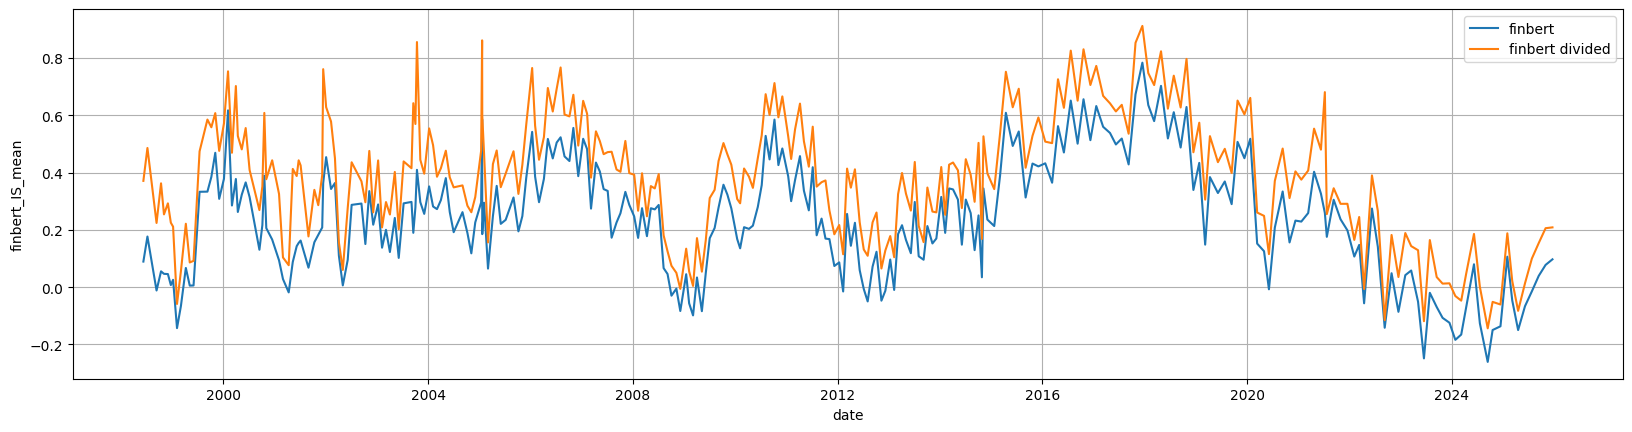

In [95]:
fig, ax = plt.subplots()
fig.set_figwidth(20)

sns.lineplot(sentiment_data, x="date",y="finbert_IS_mean", label="finbert", ax=ax)
sns.lineplot(df_pivot, x="date",y="finbert_IS_mean", label="finbert divided", ax=ax)
ax.grid()
ax.legend()

In [128]:
data[["MRO", "MRO announced"]]

,MRO,MRO announced
date,,
1999-01-07,3.00,3.00
1999-02-04,3.00,3.00
1999-03-04,3.00,3.00
1999-04-08,3.00,2.50
1999-05-06,2.50,2.50
...,...,...
2025-06-05,2.40,2.15
2025-07-24,2.15,2.15
2025-09-11,2.15,2.15


<Axes: xlabel='date', ylabel='roberta_IS_mean_diff'>

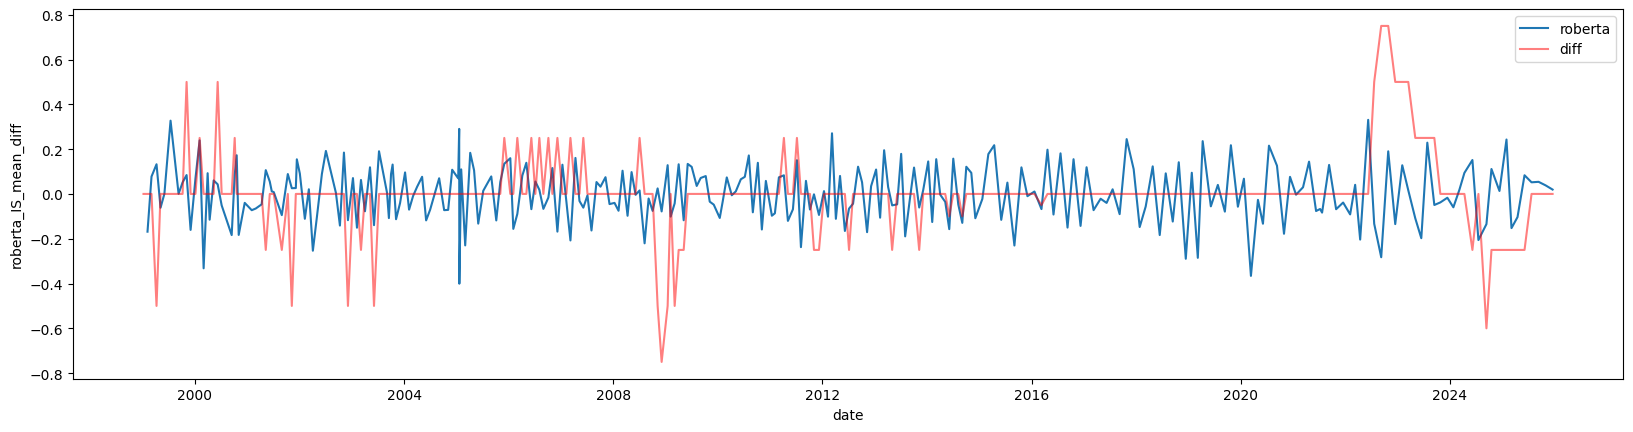

In [162]:
fig, ax = plt.subplots()
fig.set_figwidth(20)
data["MRO_diff"] = data["MRO announced"] - data["MRO"]
data["roberta_IS_mean_diff"] = data["finbert_IS_mean"].diff(1)
sns.lineplot(data, x="date",y="roberta_IS_mean_diff", label="roberta", ax=ax)

sns.lineplot(data, x="date",y="MRO_diff", label="diff",color="red", alpha=0.5, ax=ax)

In [163]:
data[["MRO_diff","roberta_IS_mean_diff"]].corr()

,MRO_diff,roberta_IS_mean_diff
MRO_diff,1.000000,0.009505
roberta_IS_mean_diff,0.009505,1.000000


In [164]:
data['sentiment_gap'] = data['finbert_IS_mean'] - data['finbert_QA_mean']
data["roberta_QA_mean_diff"] = data["roberta_QA_mean"].diff()

In [165]:
# Zameraj sa na obdobie 'Zero Lower Bound'
zlb_period = data.loc['2014-01-01':'2021-12-31']
correlation_zlb = zlb_period.corr()['Wu-Xia shadow rate'].loc[sentiment_columns.columns]
print(f"Korelácia počas nulových sadzieb: \n{correlation_zlb}")

Korelácia počas nulových sadzieb: 
finbert_IS_max     0.106354
roberta_IS_max     0.165335
finbert_QA_max    -0.109180
roberta_QA_max    -0.009714
finbert_IS_mean    0.002000
roberta_IS_mean    0.016153
finbert_QA_mean   -0.466509
roberta_QA_mean   -0.348118
finbert_IS_min    -0.057557
roberta_IS_min    -0.222195
finbert_QA_min    -0.100519
roberta_QA_min    -0.039835
finbert_IS_std     0.049208
roberta_IS_std     0.430813
finbert_QA_std     0.086371
roberta_QA_std    -0.078041
Name: Wu-Xia shadow rate, dtype: float64


In [166]:
# Zameraj sa na obdobie 'Zero Lower Bound'
zlb_period = data.loc[:'2014-01-01']
correlation_zlb = zlb_period.corr()['MRO_diff'].loc[sentiment_columns.columns]
print(f"Korelácia počas nulových sadzieb:\n{correlation_zlb}")

Korelácia počas nulových sadzieb:
finbert_IS_max     0.050355
roberta_IS_max     0.131073
finbert_QA_max     0.048216
roberta_QA_max     0.093464
finbert_IS_mean    0.437631
roberta_IS_mean    0.205136
finbert_QA_mean    0.277864
roberta_QA_mean    0.144624
finbert_IS_min     0.080212
roberta_IS_min     0.024020
finbert_QA_min     0.133312
roberta_QA_min     0.025159
finbert_IS_std    -0.235515
roberta_IS_std     0.212904
finbert_QA_std    -0.192961
roberta_QA_std     0.122659
Name: MRO_diff, dtype: float64


KeyError: 'Wu-Xia shadow rate'

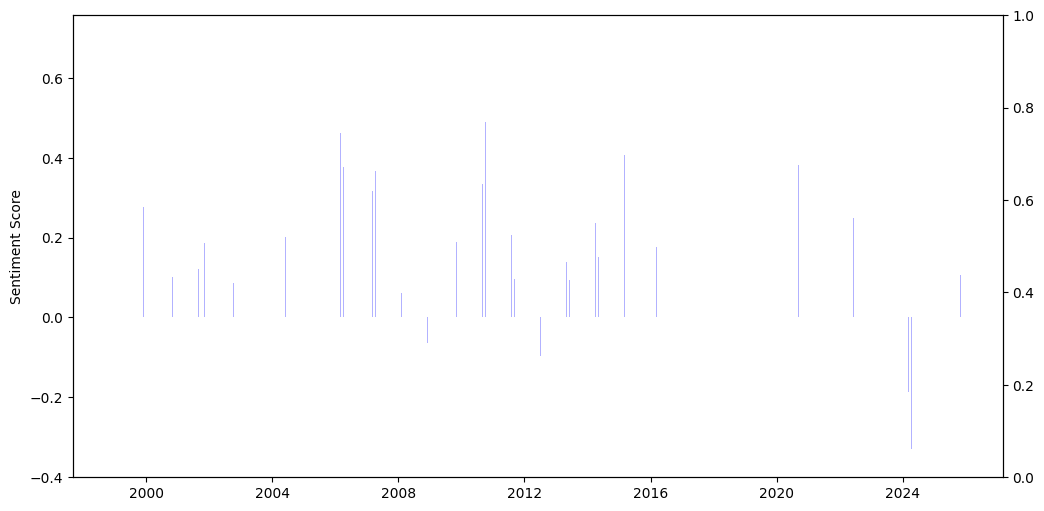

In [5]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Os X: Čas, Os Y1: Sentiment
ax1.bar(data.index, data['finbert_IS_mean'], color='blue', alpha=0.3, label='QA Sentiment')
ax1.set_ylabel('Sentiment Score')

# Druhá os Y2: Zmena sadzieb (Shadow rate alebo Euribor)
ax2 = ax1.twinx()
ax2.plot(data.index, data['Wu-Xia shadow rate'], color='red', label='Shadow Rate')
ax2.set_ylabel('Shadow Rate (%)')

plt.title("Sentiment vs. Real Policy Rate Evolution")
plt.show()

In [174]:
# 1. Rozdelíme sentiment do decilov (desatín)
data['sentiment_decile'] = pd.qcut(data['finbert_QA_mean'], 10, labels=False)

# 2. Pozrieme sa na priemerný pohyb tieňovej sadzby v každom decile
analysis = data.groupby('sentiment_decile')['Wu-Xia shadow rate'].diff().mean()

# Ak uvidíš, že v 1. decile (najviac dovish) sadzba padá oveľa viac 
# ako v 5. decile (neutral), tak máš vyhrané bez ohľadu na koreláciu.
print(analysis)

-0.4191240734463277


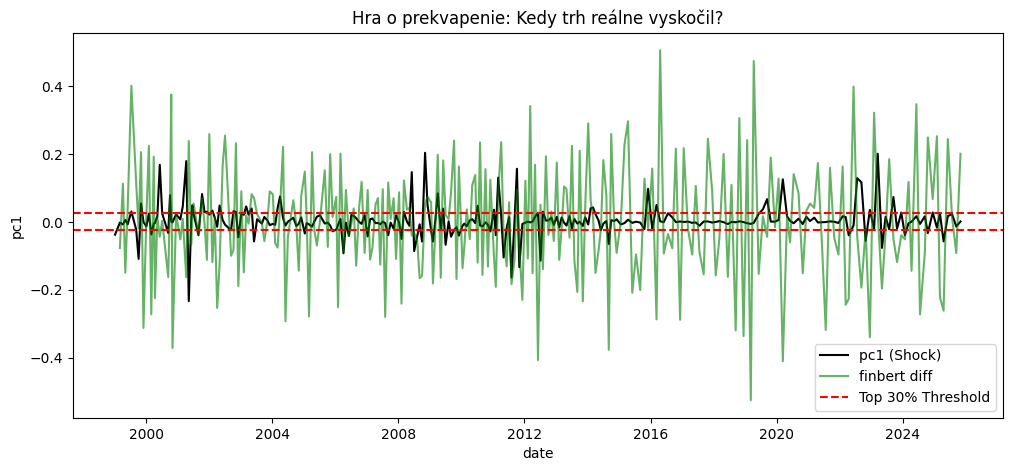

In [ ]:


# 1. Časový rad s vyznačeným thresholdom
threshold = data["pc1"].abs().quantile(0.7)
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data, x="date", y="pc1", label="pc1 (Shock)", color="black", alpha=1, ax=ax
)
sns.lineplot(data,x="date", y=data["finbert_IS_mean"].diff(),alpha=0.6, label="finbert diff", color="green", ax=ax)
ax.axhline(threshold, color="red", linestyle="--", label="Top 30% Threshold")
ax.axhline(-threshold, color="red", linestyle="--")
ax.set_title("Hra o prekvapenie: Kedy trh reálne vyskočil?")
ax.legend()
None

In [183]:
print("Autokorelácia (lag 1):", data['pc1'].autocorr())

Autokorelácia (lag 1): -0.19577121278905404
